# **Prediksi .. | Random Forest**

Model prediksi ... menggunakan algoritma Random Forest.

## 1. Data Understanding  

### 1.1 Import Library

In [2]:
# Import Library yang dibutuhkan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



### 1.2 Import & Data Understanding 

In [3]:
# Impor 'Chocolate Sales (2).csv' dataset
coklat = pd.read_csv('Chocolate Sales (2).csv')

In [4]:
# Tampilkan 5 data teratas
print('\n5 baris teratas:')
coklat.head()


5 baris teratas:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [5]:
# Tampilkan informasi dataset 
print('\nInformasi Dataset:')
coklat.info()


Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Sales Person   3282 non-null   str  
 1   Country        3282 non-null   str  
 2   Product        3282 non-null   str  
 3   Date           3282 non-null   str  
 4   Amount         3282 non-null   str  
 5   Boxes Shipped  3282 non-null   int64
dtypes: int64(1), str(5)
memory usage: 154.0 KB


In [6]:
# Tampilkan dimensi dataset
print('\nDimensi dataset:')
print('Jumlah baris:', coklat.shape[0])
print('Jumlah fitur:', coklat.shape[1])


Dimensi dataset:
Jumlah baris: 3282
Jumlah fitur: 6


In [7]:
# Tampilkan total nilai unik per fitur
print('\nTotal nilai unik per fitur:')
coklat.nunique()


Total nilai unik per fitur:


Sales Person       25
Country             6
Product            22
Date              504
Amount           3013
Boxes Shipped     507
dtype: int64

In [8]:
# Fungsi tampilkan nilai unik
def unique_values(features_name):
    print(f'\nNilai unik fitur {features_name}')
    print('Total nilai unik:', coklat[features_name].nunique())
    print('Tipe data:', coklat[features_name].dtypes)
    print('\nNilai unik:', coklat[features_name].unique())

In [9]:
# Tampilkan fitur dalam dataset 
print('\nFitur:', coklat.columns)


Fitur: Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='str')


In [10]:
# Panggil fungsi 
unique_values('Amount')


Nilai unik fitur Amount
Total nilai unik: 3013
Tipe data: str

Nilai unik: <StringArray>
[ '$5,320.00',  '$7,896.00',  '$4,501.00', '$12,726.00', '$13,685.00',
  '$5,376.00',  '$3,080.00',  '$3,990.00',  '$2,835.00',  '$4,704.00',
 ...
  '$9,976.22',  '$9,152.72',  '$9,251.37',  '$3,634.26',    '$352.51',
  '$5,303.58',  '$7,339.32',    '$616.09',  '$2,504.62',  '$5,915.87']
Length: 3013, dtype: str


In [11]:
# Menangani nilai fitur 'Amount'
coklat['Amount'] = coklat['Amount'].replace('[/$,]', '', regex=True).astype(float)
coklat['Amount'].head()

0     5320.0
1     7896.0
2     4501.0
3    12726.0
4    13685.0
Name: Amount, dtype: float64

In [12]:
# Tampilkan 5 baris teratas fitur 'Date'
coklat['Date'].head()

0    04/01/2022
1    01/08/2022
2    07/07/2022
3    27/04/2022
4    24/02/2022
Name: Date, dtype: str

In [13]:
# Menangani nilai fitur 'Date'
coklat['Date'] = pd.to_datetime(coklat['Date'], dayfirst=True)

coklat['YearMonth'] = coklat['Date'].dt.to_period('M')
coklat['Month'] = coklat['Date'].dt.month


In [14]:
# Tampilkan tipe data per fitur
print('\nTipe data per fitur:')
coklat.dtypes


Tipe data per fitur:


Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
YearMonth             period[M]
Month                     int32
dtype: object

### 1.3 Missing Value & Data Duplikat 

#### 1.3.1 Missing Value

In [15]:
# Tampilkan total nilai kosong 
print('\nTotal nilai kosong:', coklat.isnull().sum().sum())


Total nilai kosong: 0


#### 1.3.2 Data Duplikat 

In [16]:
# Tampilkan total data duplikat
print('\nTotal data duplikat:', coklat.duplicated().sum())


Total data duplikat: 0


---

### **Kesimpulan Data Understanding:**
- Dataset berisi data kinerja penjualan cokelat global pada beberapa negara dengan informasi nama perwakilan penjualan, negara, variant cokelat, tanggal penjualan, dan total penjualan.
- Tidak ada target yang ditentukan secara langsung untuk dataset ini. Sehingga kami akan analysis pada tahap EDA.
- Struktur data cenderung memiliki tipe data kategorikal yang akan kami tangani nanti.

----

## 2. Exploratory Data Analysis (EDA)

### 2.1 Multivariate Analysis

In [17]:
# Tampilkan Statistik dataset
print('\nStatistik dataset:')
coklat.describe()


Statistik dataset:


,Date,Amount,Boxes Shipped,Month
count,3282,3282.000000,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252285,6030.338775,164.666971,4.576782
min,2022-01-03 00:00:00,7.000000,1.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000,3.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000,5.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000,7.000000
max,2024-08-31 00:00:00,26170.950000,778.000000,8.000000
std,NaN,4393.980200,124.024736,2.315759


In [18]:
# Tampilkan perbandingan selisih nilai
def value_difference(features_name):
    max_value = coklat[features_name].max()
    median = coklat[features_name].quantile(0.50)
    quantile_75 = coklat[features_name].quantile(0.75)

    selisih1 = quantile_75 - median
    selisih2 = max_value - quantile_75

    print('\nTotal selisih nilai median dengan kuantil 75:', selisih1)
    print('Total selisih kuantil 75 dengan max:', selisih2)

value_difference('Amount')
value_difference('Boxes Shipped')


Total selisih nilai median dengan kuantil 75: 3331.3425000000007
Total selisih kuantil 75 dengan max: 17614.1075

Total selisih nilai median dengan kuantil 75: 95.0
Total selisih kuantil 75 dengan max: 546.0


Jarak quantile 75% dengan nilai max memiliki selisih yang cukup jauh yakni 546. Sedangkan, jika dibandingkan dengan selisih median dengan quantile 75 yang memiliki nilai hanya 95, ini cukup jauh. Ini bisa berpotensi terdapat nilai yang diluar rata-rata pada fitur tersebut. Begitu juga dengan fitur 'Amount'. 

In [19]:
# Tampilkan statistik fitur kategorikal
print('\nStatistik fitur kategori:')
coklat.describe(include=['category', 'object'])


Statistik fitur kategori:


/tmp/ipykernel_112457/2416872851.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  coklat.describe(include=['category', 'object'])


,Sales Person,Country,Product
count,3282,3282,3282
unique,25,6,22
top,Kelci Walkden,Australia,50% Dark Bites
freq,162,615,180


### 2.2 Univariate Analysis

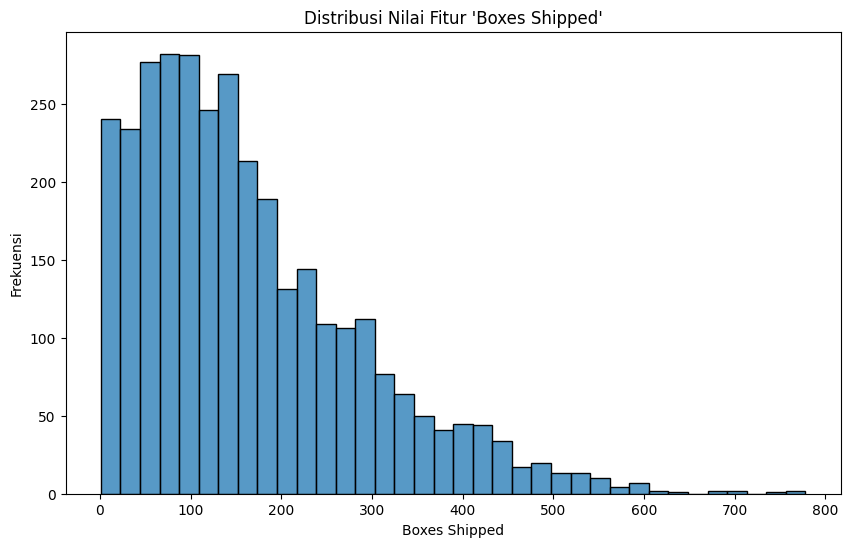

In [20]:
# Tampilkan penyebaran fitur numerik
plt.figure(figsize=(10, 6))
sns.histplot(data=coklat['Boxes Shipped'])
plt.ylabel('Frekuensi')
plt.title("Distribusi Nilai Fitur 'Boxes Shipped'")
plt.show()

Distribusi nilai cenderung skew-right.

/tmp/ipykernel_112457/84662986.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = coklat.select_dtypes(include=['category', 'object']).columns


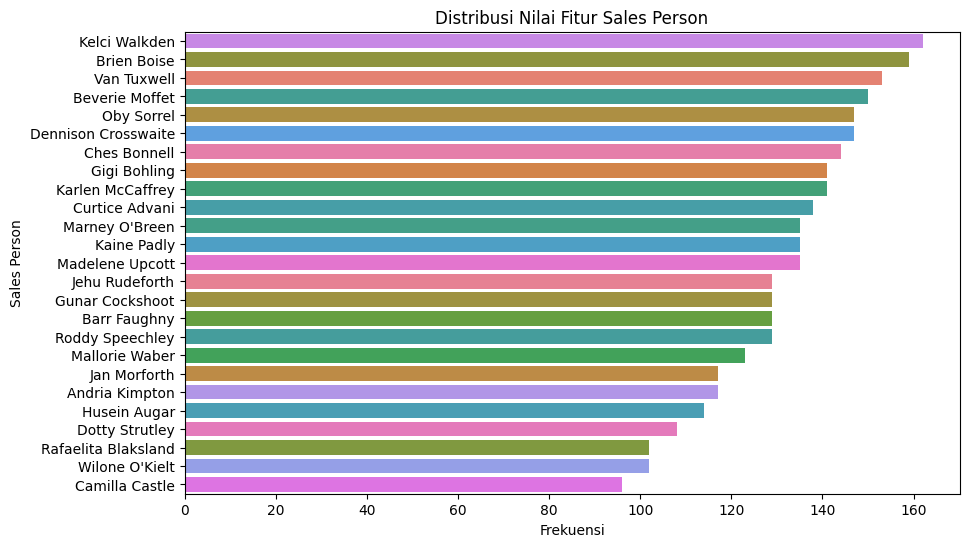

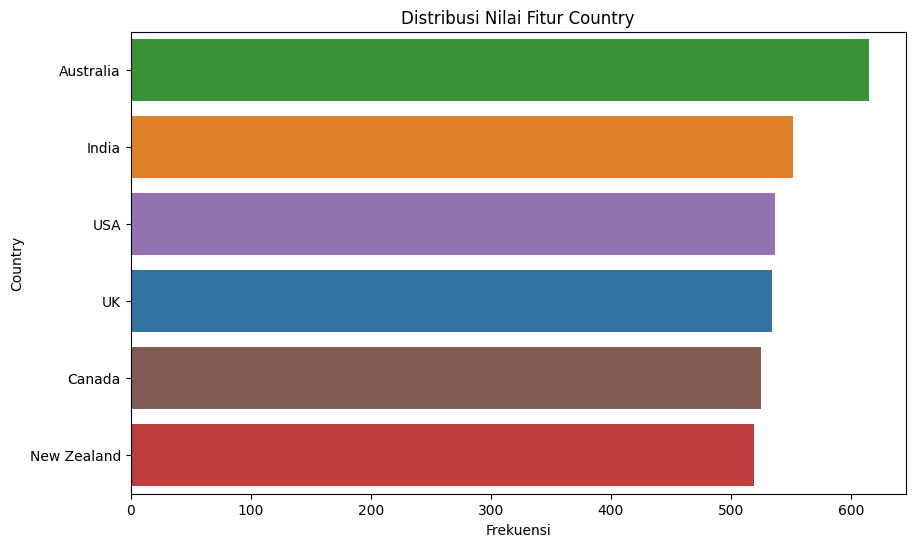

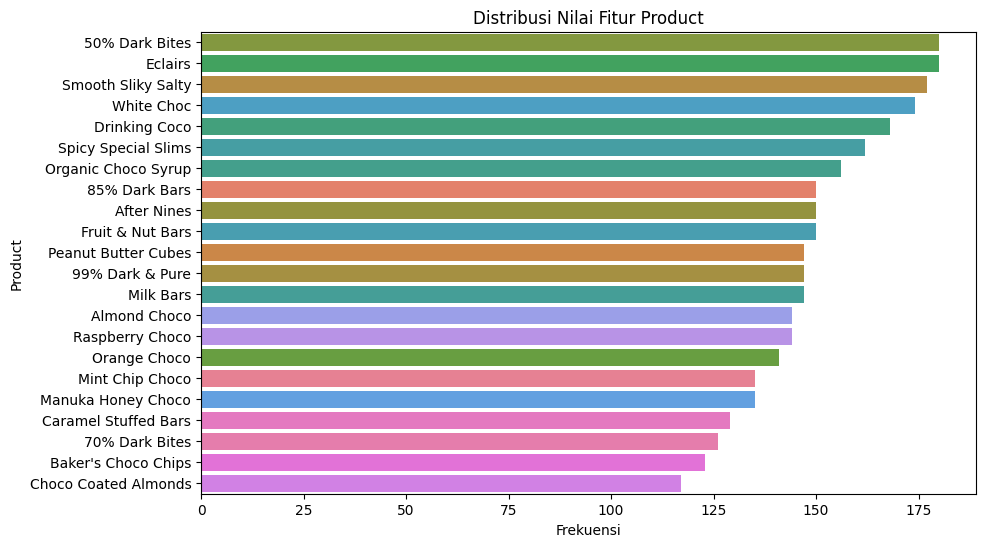

In [21]:
# Ambil fitur kategorikal tapi exclude 'Date'
cat_cols = coklat.select_dtypes(include=['category', 'object']).columns

for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=coklat, y=col, order=coklat[col].value_counts().index, hue=coklat[col])
    plt.xlabel('Frekuensi')
    plt.title(f'Distribusi Nilai Fitur {col}')
    plt.show()


- Sales Pearson -> Pekerja yang memiliki penjualan yakni Kelci Walkden. Sedangkan yang terendah yakni Camila Casle.
- Country -> Distirbusi coklat terbanyak adalah negara Australia. Sedangkan, yang paling rendah yakni New Zeeland.
- Product -> Penjualan terbanyak yakni coklat variant Eclairs dan 50% Dark Bites. Sedangkan, penjualan terdikit coklat variant Choco Coated Almonds.

In [22]:
coklat.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,YearMonth,Month
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180,2022-01,1
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022-08,8
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022-07,7
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022-04,4
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184,2022-02,2


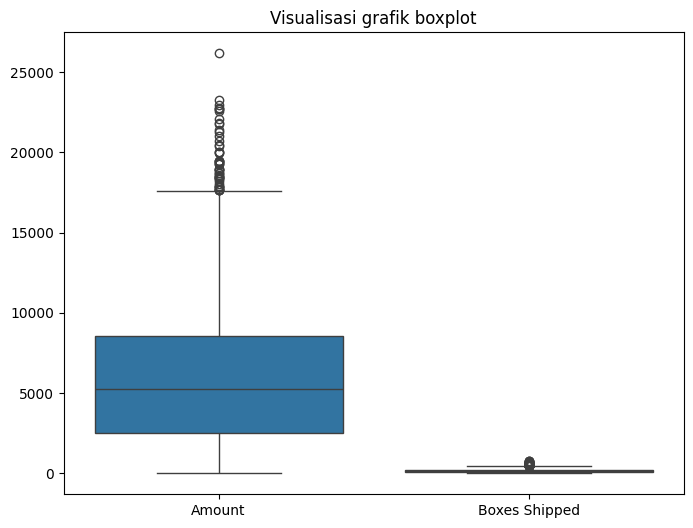

In [23]:
# Visualisi boxplot
num_cols = coklat.select_dtypes(include=['int64', 'float64'])


plt.figure(figsize=(8, 6))
sns.boxplot(data=num_cols)
plt.title('Visualisasi grafik boxplot')
plt.show()

Terdapat nilai yang diluar rata - rata, pada fitur numerik diatas. Namun, kami memilih untuk tidak menanganinya karena itu masih masuk akal yang kemungkinan itu adalah variasi dari nilai. Juga, model Random Forest tidak sensitif terhadap outlier, karena model memprediksi dengan thershold.

### 2.3 Bivariate Analysis

/tmp/ipykernel_112457/3852621803.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(labels)


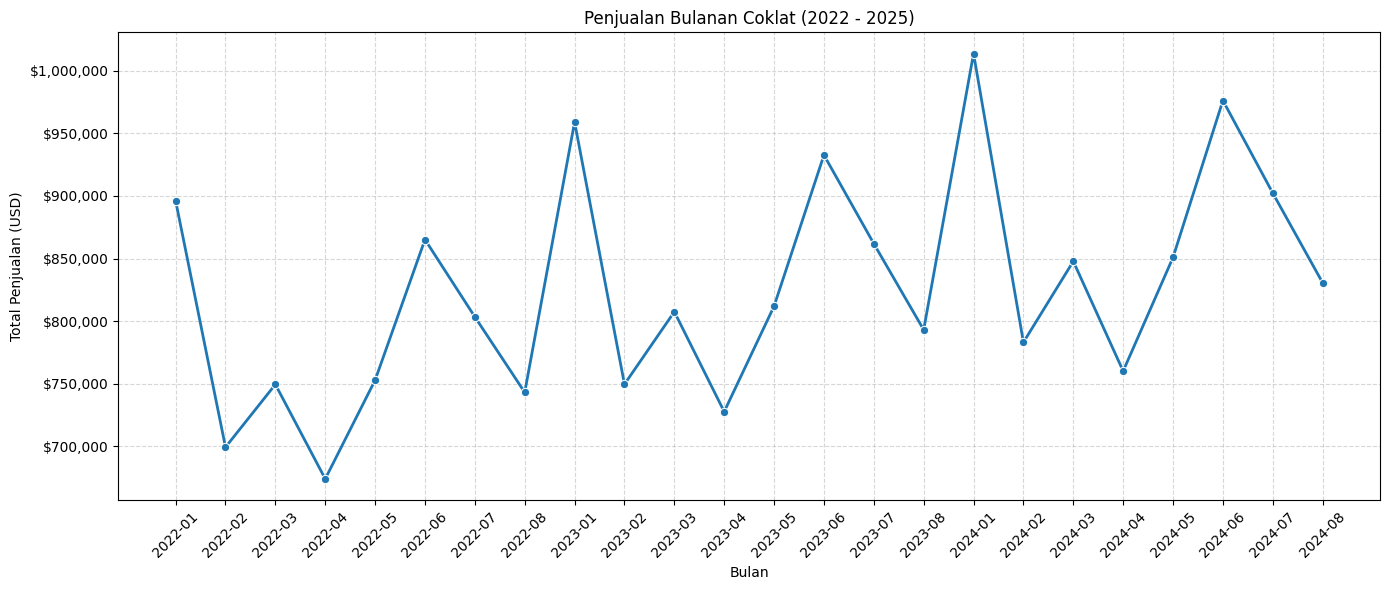

In [24]:
monthly_trend = coklat.groupby('YearMonth')['Amount'].sum().reset_index()
monthly_trend['YearMonth'] = monthly_trend['YearMonth'].astype(str)

plt.figure(figsize=(14, 6))
ax1 = sns.lineplot(data=monthly_trend, x='YearMonth', y='Amount', marker='o', linewidth=2)
ticks = ax1.get_yticks()    
labels = [f'${x:,.0f}' for x in ticks]
ax1.set_yticklabels(labels)
plt.title('Penjualan Bulanan Coklat (2022 - 2025)')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan (USD)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- Penjualaan tertinggi pada suatu tahun tertentu selalu ada pada bulan januari,  sedangkan penjualan terrendah seallu pada bulan april. 

/tmp/ipykernel_112457/448781420.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_person, x='Amount', y='Sales Person', ax=axes[0], palette='viridis')
/tmp/ipykernel_112457/448781420.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_country, x='Amount', y='Country', ax=axes[1], palette='magma')


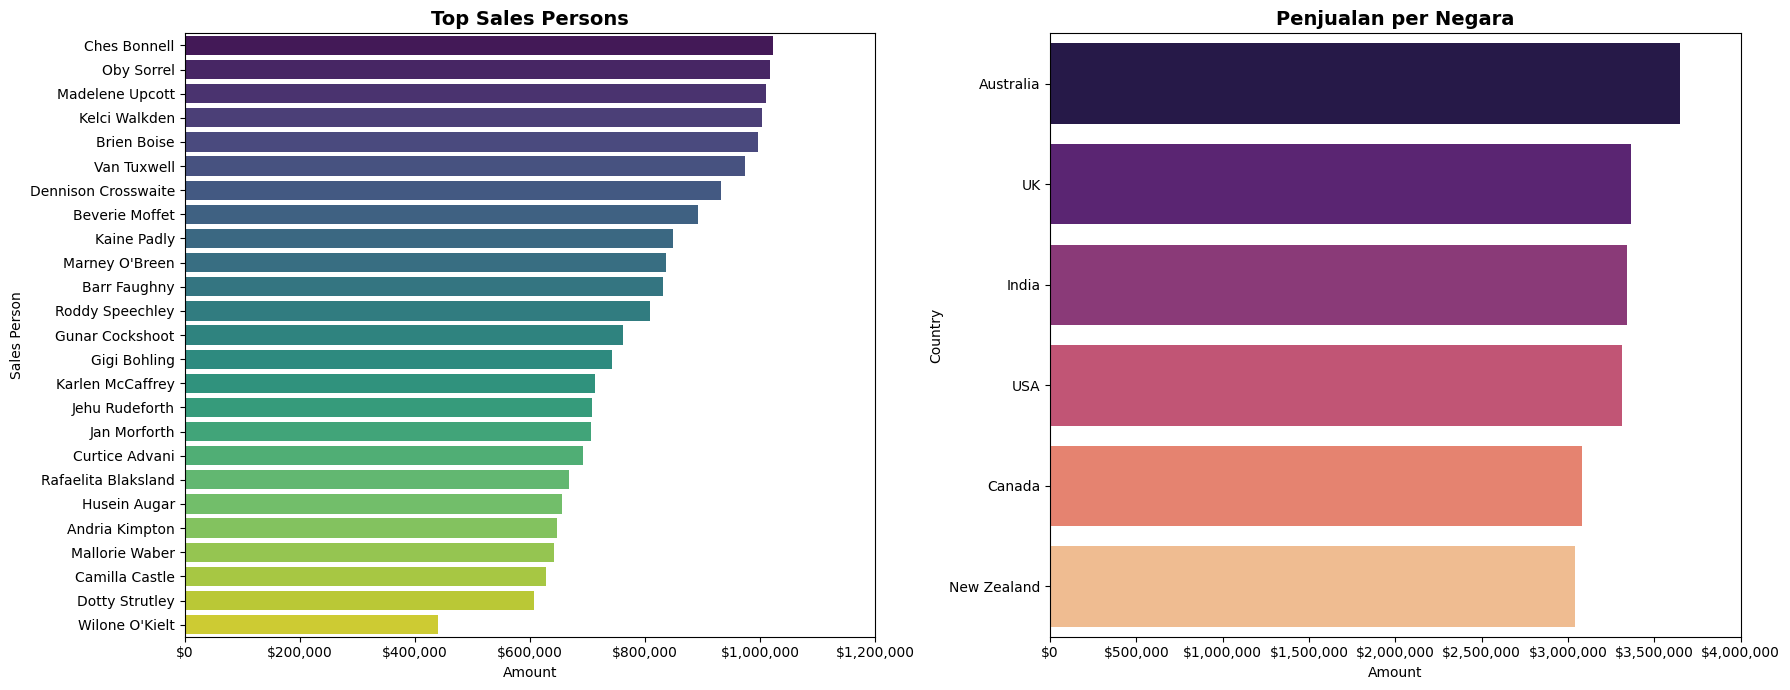

In [25]:
sales_by_person = coklat.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False).reset_index()
sales_by_country = coklat.groupby('Country')['Amount'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grafik sales pearson dengan amount
sns.barplot(data=sales_by_person, x='Amount', y='Sales Person', ax=axes[0], palette='viridis')
axes[0].set_title('Top Sales Persons', fontsize=14, fontweight='bold')

# Set untuk nilai amount -> dolar
ticks_x0 = axes[0].get_xticks()
axes[0].set_xticks(ticks_x0)
axes[0].set_xticklabels([f'${x:,.0f}' for x in ticks_x0])

# Grafik amount dengan country
sns.barplot(data=sales_by_country, x='Amount', y='Country', ax=axes[1], palette='magma')
axes[1].set_title('Penjualan per Negara', fontsize=14, fontweight='bold')

# Set untuk nilaiamount -> dolar
ticks_x1 = axes[1].get_xticks()
axes[1].set_xticks(ticks_x1)
axes[1].set_xticklabels([f'${x:,.0f}' for x in ticks_x1])

plt.tight_layout()
plt.show()

- Total nilai penjualan yang tertinggi adalah dilakukan oleh sales Ches Bonnel. Sedangkan, nilai penjulan yang terendah adalah dilakukan oleh sales Wilone O'Kielt.
- Nilai penjualan ke negara Australia adalah yang tertinggi. Sedangkan, pendapatan dari penjualan terendah yakni negara New Zeeland.

In [26]:
coklat.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,YearMonth,Month
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180,2022-01,1
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022-08,8
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022-07,7
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022-04,4
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184,2022-02,2


## 3. Data Preparation 

In [27]:
# Encoding data kategorikal 
cat_cols = coklat.select_dtypes(include=['category', 'object'])

for col in cat_cols:
    coklat[col] = pd.factorize(coklat[col])[0]

coklat.head()

/tmp/ipykernel_112457/189827937.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = coklat.select_dtypes(include=['category', 'object'])


,Sales Person,Country,Product,Date,Amount,Boxes Shipped,YearMonth,Month
0,0,0,0,2022-01-04,5320.0,180,2022-01,1
1,1,1,1,2022-08-01,7896.0,94,2022-08,8
2,2,1,2,2022-07-07,4501.0,91,2022-07,7
3,3,2,2,2022-04-27,12726.0,342,2022-04,4
4,0,0,2,2022-02-24,13685.0,184,2022-02,2


In [35]:
X = coklat.drop(['Amount', 'Date', 'YearMonth'], axis=1)
y = coklat['Amount']

In [36]:
def random_split(X, y, size=0.8):
    np.random.seed(42)
    idx = np.random.permutation(len(X))
    split = int(len(X) * size)

    X_train = X.iloc[idx[:split]]
    y_train = y.iloc[idx[:split]]
    X_test = X.iloc[idx[split:]]
    y_test = y.iloc[idx[split:]]

    return X_train, y_train, X_test, y_test

In [37]:
X_train, y_train, X_test, y_test = random_split(X, y)

In [38]:
# Fungsi untuk menghitung Variance (pengganti Gini untuk Regresi)
# Variance = rata-rata dari kuadrat selisih antara setiap titik data dan rata-rata (mean)
def calculate_variance(y):
    if len(y) == 0:
        return 0
    mean = np.mean(y)
    return np.mean((y - mean) ** 2)

# Class Node untuk menyimpan informasi tiap node di pohon
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature      # Indeks fitur yang dipakai untuk split
        self.threshold = threshold  # Nilai threshold (midpoint) untuk split
        self.left = left            # Child node kiri
        self.right = right          # Child node kanan
        self.value = value          # Nilai prediksi (hanya ada di Leaf Node)

In [39]:
def get_best_split(X, y, num_features):
    best_split = {}
    max_gain = -float("inf")
    
    # Variance sebelum di-split (Parent node)
    parent_variance = calculate_variance(y)
    
    n_samples, n_features = X.shape
    
    # RANDOM FOREST: Memilih fitur secara acak (Random Feature Subspace)
    # Kita tidak mengecek semua fitur, tapi hanya sebagian acak
    feature_indices = np.random.choice(n_features, num_features, replace=False)
    
    # Loop tiap fitur yang terpilih
    for feature_idx in feature_indices:
        feature_values = X[:, feature_idx]
        possible_thresholds = np.unique(feature_values)
        
        # Loop tiap kemungkinan threshold (Midpoint)
        for i in range(len(possible_thresholds) - 1):
            # 1. Hitung Midpoint antara dua nilai berurutan
            threshold = (possible_thresholds[i] + possible_thresholds[i+1]) / 2
            
            # Split data berdasarkan threshold
            left_indices = np.where(feature_values <= threshold)[0]
            right_indices = np.where(feature_values > threshold)[0]
            
            if len(left_indices) == 0 or len(right_indices) == 0:
                continue
            
            # Ambil target value (y) untuk kiri dan kanan
            y_left, y_right = y[left_indices], y[right_indices]
            
            # 2. Hitung Impurity (Variance) tiap sisi (Left & Right)
            var_left = calculate_variance(y_left)
            var_right = calculate_variance(y_right)
            
            # 3. Hitung Impurity After (Weighted Variance)
            # Rumus: (n_kiri/n_total * var_kiri) + (n_kanan/n_total * var_kanan)
            n = len(y)
            n_l, n_r = len(y_left), len(y_right)
            weighted_variance = (n_l / n) * var_left + (n_r / n) * var_right
            
            # 4. Hitung Gain (Variance Reduction)
            # Semakin besar Gain, semakin bagus splitnya
            gain = parent_variance - weighted_variance
            
            # 5. Cari Threshold dengan Gain Terbesar (Impurity After Terkecil)
            if gain > max_gain:
                max_gain = gain
                best_split = {
                    "feature_index": feature_idx,
                    "threshold": threshold,
                    "left_indices": left_indices,
                    "right_indices": right_indices,
                    "gain": gain
                }
                
    return best_split

In [40]:
class DecisionTreeRegressor:
    def __init__(self, min_samples_split=2, max_depth=100, num_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.num_features = num_features # Jumlah fitur acak yang dicek
        self.root = None

    def fit(self, X, y):
        # Jika num_features tidak ditentukan, gunakan semua fitur (behavior default Decision Tree)
        # Tapi untuk Random Forest nanti kita set ini lebih kecil dari total fitur
        self.num_features = X.shape[1] if not self.num_features else self.num_features
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Kondisi berhenti (Leaf Node Logic):
        # 1. Sudah mencapai kedalaman maksimum
        # 2. Jumlah sampel kurang dari minimum split
        # 3. Varians sudah 0 (semua nilai y sama)
        if (depth >= self.max_depth or n_samples < self.min_samples_split or n_labels == 1):
            leaf_value = np.mean(y) # Nilai prediksi adalah rata-rata y di node ini
            return Node(value=leaf_value)

        # Cari Split Terbaik (Akar/Cabang)
        best_split = get_best_split(X, y, self.num_features)
        
        # Jika tidak ada gain (tidak bisa split lagi), jadikan leaf
        if best_split.get("gain", 0) == 0:
            return Node(value=np.mean(y))

        # Rekursi: Bangun pohon kiri dan kanan
        # Ini langkah "cari gini after terkecil sampai nemu leaf node"
        left_node = self._grow_tree(X[best_split["left_indices"]], y[best_split["left_indices"]], depth + 1)
        right_node = self._grow_tree(X[best_split["right_indices"]], y[best_split["right_indices"]], depth + 1)

        return Node(best_split["feature_index"], best_split["threshold"], left_node, right_node)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

In [43]:
class RandomForestRegressor:
    def __init__(self, n_trees=10, min_samples_split=2, max_depth=5, num_features=None):
        self.n_trees = n_trees
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.num_features = num_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            # 1. BAGGING (Bootstrap Aggregating)
            # Ambil sampel data secara acak dengan pengembalian (replace=True)
            n_samples = X.shape[0]
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X[idxs], y[idxs]
            
            # Buat Decision Tree baru
            tree = DecisionTreeRegressor(
                min_samples_split=self.min_samples_split,
                max_depth=self.max_depth,
                num_features=self.num_features
            )
            
            # Latih pohon pada sampel bootstrap
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        # 2. AGGREGATION (Gabungkan prediksi tiap pohon)
        # Ambil prediksi dari setiap pohon
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # Hitung rata-rata semua prediksi pohon (Mean)
        # Ini langkah terakhir "gabungkan prediksi tiap pohon"
        final_predictions = np.mean(tree_preds, axis=0)
        return final_predictions

In [44]:
model_rf = RandomForestRegressor()
model_rf.fit(X_train.select_dtypes(include=[np.number]).values, y_train.values)

In [ ]:
def tune_random_forest(X_train, y_train, X_test, y_test, tree_candidates, depth_candidates):
    results = []
    best_params = None
    min_rmse = float('inf')
    
    
    # Loop 1: Jumlah Pohon
    for n_trees in tree_candidates:
        # Loop 2: Kedalaman Pohon
        for depth in depth_candidates:
            
            # 1. Inisialisasi Model dengan parameter saat ini
            # num_features=2 (bisa disesuaikan, atau akar dari total fitur)
            rf = RandomForestRegressor(n_trees=n_trees, max_depth=depth, num_features=2)
            
            # 2. Training
            rf.fit(X_train.select_dtypes(include=[np.number]).values, y_train.values)
            
            # 3. Validasi / Prediksi
            preds = rf.predict(X_test.select_dtypes(include=[np.number]).values)
            
            # 4. Hitung Error (RMSE)
            current_rmse = np.sqrt(np.mean((y_test - preds) ** 2))
            
            # Simpan hasil
            results.append({
                'n_trees': n_trees,
                'max_depth': str(depth), # Convert ke string agar 'None' terbaca jelas
                'RMSE': current_rmse
            })
            
            # Cek apakah ini skor terbaik?
            if current_rmse < min_rmse:
                min_rmse = current_rmse
                best_params = {'n_trees': n_trees, 'max_depth': depth}
                
            print(f"> Trees: {n_trees:<3} | Depth: {str(depth):<4} | RMSE: {current_rmse:.4f}")

    print("-" * 50)
    return best_params, results

In [68]:
# 1. Tentukan Kandidat Parameter
# Tips: 
# - Trees: Coba angka kecil dulu biar cepat, lalu angka besar untuk stabilitas.
# - Depth: None artinya pohon tumbuh bebas (hati-hati overfitting), angka kecil (3-5) menahan bias.
candidate_trees = list(range(2,11)) 
candidate_depths = list(range(3,11)) 

# 2. Jalankan Tuning
# (Pastikan X_train, y_train, dll sudah ada dari cell data sebelumnya)
best_param, history = tune_random_forest(
    X_train, y_train, 
    X_test, y_test, 
    candidate_trees, 
    candidate_depths
)

# 3. Tampilkan Kesimpulan
print("\n=== HASIL AKHIR TUNING ===")
print(f"Jumlah Pohon : {best_param['n_trees']}")
print(f"Max Depth    : {best_param['max_depth']}")
print(f"RMSE Terkecil: {min(d['RMSE'] for d in history):.4f}")

# (Optional) Jika ingin melihat tabel perbandingan sederhana
# print("\n--- Tabel Perbandingan ---")
# # Mengurutkan hasil dari error terkecil ke terbesar
# sorted_history = sorted(history, key=lambda x: x['RMSE'])
# for i, item in enumerate(sorted_history[:5]): # Tampilkan Top 5
#     print(f"Rank {i+1}: Trees={item['n_trees']}, Depth={item['max_depth']} -> RMSE={item['RMSE']:.4f}")

Mulai Tuning... Total kombinasi: 72
--------------------------------------------------
> Trees: 2   | Depth: 3    | RMSE: 4668.4555
> Trees: 2   | Depth: 4    | RMSE: 4606.3812
> Trees: 2   | Depth: 5    | RMSE: 4604.6881
> Trees: 2   | Depth: 6    | RMSE: 4481.6188
> Trees: 2   | Depth: 7    | RMSE: 4490.1476
> Trees: 2   | Depth: 8    | RMSE: 4287.9798
> Trees: 2   | Depth: 9    | RMSE: 4064.3461
> Trees: 2   | Depth: 10   | RMSE: 3933.9071
> Trees: 3   | Depth: 3    | RMSE: 4626.6002
> Trees: 3   | Depth: 4    | RMSE: 4628.0563
> Trees: 3   | Depth: 5    | RMSE: 4536.9363
> Trees: 3   | Depth: 6    | RMSE: 4424.7296
> Trees: 3   | Depth: 7    | RMSE: 4421.1205
> Trees: 3   | Depth: 8    | RMSE: 4275.5496
> Trees: 3   | Depth: 9    | RMSE: 4042.6910
> Trees: 3   | Depth: 10   | RMSE: 3917.1315
> Trees: 4   | Depth: 3    | RMSE: 4633.7640
> Trees: 4   | Depth: 4    | RMSE: 4612.6300
> Trees: 4   | Depth: 5    | RMSE: 4536.5181
> Trees: 4   | Depth: 6    | RMSE: 4437.2481
> Trees: 4   

In [70]:
# final model
final_model = RandomForestRegressor(
    n_trees=best_param['n_trees'], 
    max_depth=best_param['max_depth'], 
    num_features=2
)
final_model.fit(X_train.select_dtypes(include=[np.number]).values, y_train.values)

# # final model
# final_model = RandomForestRegressor(n_trees=5, max_depth=3, num_features=2)
# final_model.fit(X_train.select_dtypes(include=[np.number]).values, y_train.values)

In [71]:
# evluasi train dan tes
def evaluate(y_true, y_pred):
    eror = y_true - y_pred
    mse = np.mean(eror ** 2)
    rmse = np.sqrt(mse)
    ss = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum(eror ** 2)
    r2 = 1 - (ss_res / ss)
    mae = np.mean(np.abs(eror))
    return {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae
    }

In [72]:
final_model_train = final_model.predict(X_train.select_dtypes(include=[np.number]).values)
final_model_test = final_model.predict(X_test.select_dtypes(include=[np.number]).values)

evaluasi_train = evaluate(y_train.values, final_model_train)
evaluasi_test = evaluate(y_test.values, final_model_test)

print("Evaluasi Train")
print(f"MSE: {evaluasi_train['MSE']:.4f}")
print(f"RMSE: {evaluasi_train['RMSE']:.4f}")
print(f"R2: {evaluasi_train['R2']:.4f}")
print(f"MAE: {evaluasi_train['MAE']:.4f}")

print("\nEvaluasi Test")
print(f"MSE: {evaluasi_test['MSE']:.4f}")
print(f"RMSE: {evaluasi_test['RMSE']:.4f}")
print(f"R2: {evaluasi_test['R2']:.4f}")
print(f"MAE: {evaluasi_test['MAE']:.4f}")

Evaluasi Train
MSE: 7219875.7836
RMSE: 2686.9827
R2: 0.6124
MAE: 2051.7845

Evaluasi Test
MSE: 13275784.2095
RMSE: 3643.5950
R2: 0.3914
MAE: 2700.0070


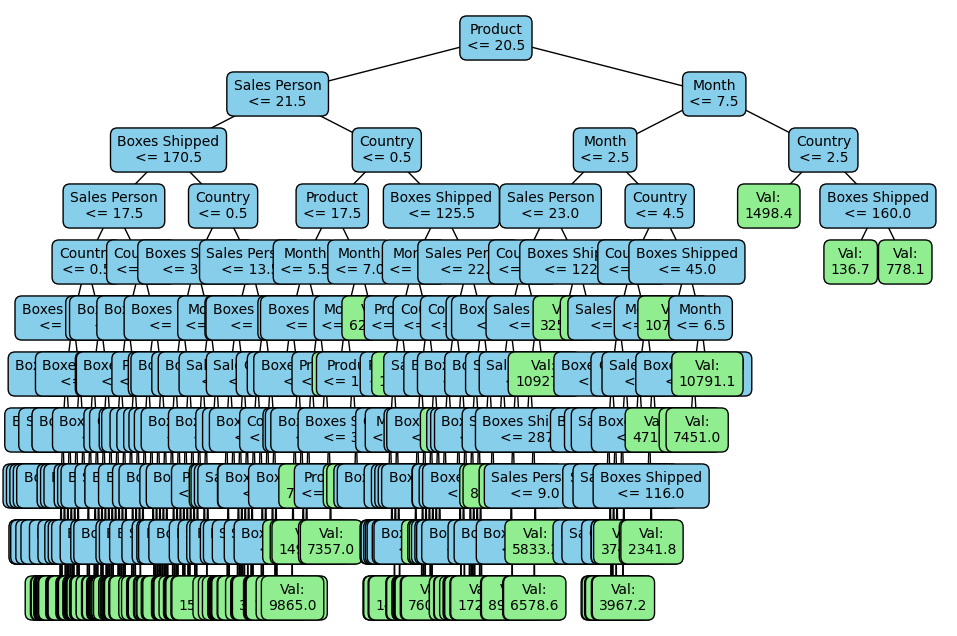

In [86]:
# import matplotlib.pyplot as plt

def plot_tree_visual(node, feature_names=None, ax=None, x=0.5, y=1.0, dx=0.5, dy=0.1):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.set_axis_off()
        
    # Tentukan Label Node
    if node.value is not None:
        text = f"Val:\n{node.value:.1f}"
        bbox_color = '#90EE90' # Warna Leaf Node
    else:
        if feature_names:
            feat = feature_names[node.feature]
        else:
            feat = f"X[{node.feature}]"
        text = f"{feat}\n<= {node.threshold:.1f}"
        bbox_color = '#87CEEB' # Warna Decision Node

    # Gambar Kotak Node
    ax.text(x, y, text, ha='center', va='center', 
            bbox=dict(boxstyle="round,pad=0.5", facecolor=bbox_color, edgecolor='black'),
            fontsize=10)

    # Jika bukan leaf, gambar garis ke anak
    if node.left:
        # Koordinat anak kiri
        next_x = x - dx / 2
        next_y = y - dy
        
        # Gambar garis
        ax.plot([x, next_x], [y, next_y], 'k-', lw=1)
        
        # Rekursi gambar anak kiri
        plot_tree_visual(node.left, feature_names, ax, next_x, next_y, dx/2, dy)
        
    if node.right:
        # Koordinat anak kanan
        next_x = x + dx / 2
        next_y = y - dy
        
        # Gambar garis
        ax.plot([x, next_x], [y, next_y], 'k-', lw=1)
        
        # Rekursi gambar anak kanan
        plot_tree_visual(node.right, feature_names, ax, next_x, next_y, dx/2, dy)

tree_to_plot = final_model.trees[0]


plot_tree_visual(tree_to_plot.root, feature_names=feature_names, x=0.5, y=1.0, dx=0.5)

plt.show()

In [87]:
import tkinter as tk
from tkinter import messagebox
root = tk.Tk()
root.configure(bg="#1A1E23")

def get_prediction():
    # Ambil input dari entry
    input1 = float(entry1.get())
    input2 = float(entry2.get())
    input3 = float(entry3.get())
    input4 = float(entry4.get())
    
    # Buat array input untuk model
    input_data = np.array([[input1, input2, input3, input4]])
    
    # Dapatkan prediksi dari model
    prediction = final_model.predict(input_data)
    
    # Tampilkan hasil prediksi
    result_label.config(text=f"Predicted Amount: ${prediction[0]:.2f}")
    result_label.pack()
    return prediction
# Frame
frame = tk.Frame(root)
frame.configure(bg="#1A1E23")
frame.place(relx=0.5, rely=0.35 ,anchor="center")

# label1
label1 = tk.Label(frame,
                  text="... Classifier",
                  font=("Arial", 40, "bold"),
                  bg="#1A1E23",
                  fg="#FFFFFF") 
label1.pack()


# entry1
entry1 = tk.Entry(frame,
                  font=("Arial", 30, 'bold'),
                  bg="#4C4C4C",
                  fg='#FFFFFF')
entry1.pack(pady=10)

entry2 = tk.Entry(frame,
                  font=("Arial", 30, 'bold'),
                  bg="#4C4C4C",
                  fg='#FFFFFF')
entry2.pack(pady=10)

entry3 = tk.Entry(frame,
                  font=("Arial", 30, 'bold'),
                  bg="#4C4C4C",
                  fg='#FFFFFF')
entry3.pack(pady=10)

entry4 = tk.Entry(frame,
                  font=("Arial", 30, 'bold'),
                  bg="#4C4C4C",
                  fg='#FFFFFF')
entry4.pack(pady=10)

# button1
button1 = tk.Button(frame,
                    text="Press",
                    font=("Arial", 26, "bold"),
                    bg="#4C4C4C",
                    fg="#FFFFFF",
                    command=get_prediction)
button1.pack()

root.mainloop()

In [81]:
coklat.sample(5)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,YearMonth,Month
1586,8,4,1,2023-08-25,14566.22,45,2023-08,8
1697,0,1,19,2023-06-06,2261.98,73,2023-06,6
1218,20,0,8,2023-01-25,5029.35,61,2023-01,1
2234,1,4,6,2024-01-13,10772.33,156,2024-01,1
2858,19,3,7,2024-06-14,9420.22,94,2024-06,6
